<a href="https://colab.research.google.com/github/shahabday/Deeplearning_challenge_erum_seasnot/blob/main/01_pytorch_dataloader_with_normalization_training_multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gdown

import gdown

url = "https://drive.google.com/file/d/1rD1GVJntPtyukfKNLt764sN13sSSwvel/view?usp=drive_link"

gdown.download(url, quiet=False, fuzzy=True)

FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel

but Gdown can't. Please check connections and permissions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

!cp /content/drive/MyDrive/indico_challenge/data/savetheoceans.nc /


In [7]:
!ls /

bin			    kaggle		      opt		 srv
boot			    lib			      proc		 sys
content			    lib32		      python-apt	 tmp
cuda-keyring_1.1-1_all.deb  lib64		      python-apt.tar.xz  tools
datalab			    libx32		      root		 usr
dev			    media		      run		 var
etc			    mnt			      savetheoceans.nc
home			    NGC-DL-CONTAINER-LICENSE  sbin


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as npa

In [3]:
data = xr.open_dataset("/savetheoceans.nc")

In [ ]:
data

<xarray.Dataset> Size: 8GB
Dimensions:  (sample: 2803, channel: 12, x: 240, y: 240)
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 288B '442nm' '492nm' '559nm' ... '2186nm' 'labels'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
Data variables:
    data     (sample, channel, x, y) float32 8GB ...

In [ ]:
sample = data["data"].sel(sample = 3 )

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
data.isel(sample=0, channel=0)

<xarray.Dataset> Size: 231kB
Dimensions:  (x: 240, y: 240)
Coordinates:
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
    sample   int16 2B 0
    channel  <U6 24B '442nm'
Data variables:
    data     (x, y) float32 230kB ...

In [5]:
da = data["data"]

In [6]:
img = da.isel(sample=0, channel=0)

print("data dtype:", da.dtype)
print("img dtype:", img.dtype)
print("img shape:", img.shape)
print("values dtype:", img.values.dtype)
print("element type:", type(img.values[0,0]))
print("element value:", img.values[0,0])

data dtype: float32
img dtype: float32
img shape: (240, 240)
values dtype: float32
element type: <class 'numpy.float32'>
element value: 0.06999265


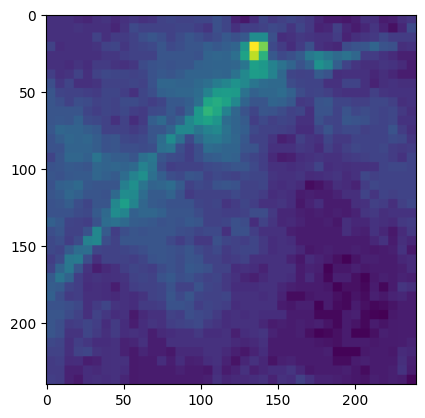

In [ ]:
plt.imshow(img)

#Classification of just Oil

## Data loader


In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset


class XarrayBinaryClassificationDataset(Dataset):
    """
    Converts segmentation labels into image-level binary classification.

    Target = 1 if target_class is present anywhere in the mask
           = 0 otherwise
    """

    def __init__(
        self,
        da,
        target_class,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
    ):
        self.da = da
        self.target_class = target_class
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        # sanity check: expected 11 input channels
        if len(self.input_channels) != 11:
            print(f"Warning: expected 11 input channels, found {len(self.input_channels)}")

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)

        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        return x.astype(np.float32)

    def _mask_to_binary_label(self, y_mask: np.ndarray) -> np.float32:
        # positive if target class exists anywhere
        label = (y_mask == self.target_class).any()
        return np.float32(label)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        y_mask = sample.sel(channel=self.label_channel).values

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self._mask_to_binary_label(y_mask)

        x = torch.from_numpy(x)                      # shape: [11, H, W]
        y = torch.tensor(y, dtype=torch.float32)    # scalar float for BCEWithLogitsLoss

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

# Train split

In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset


def extract_binary_labels_from_da(da, target_class, label_channel="labels"):
    labels = []
    for i in range(da.sizes["sample"]):
        mask = da.isel(sample=i).sel(channel=label_channel).values
        labels.append(int((mask == target_class).any()))
    return np.array(labels)


def make_dataloaders(
    da,
    target_class,
    label_channel="labels",
    batch_size=16,
    num_workers=4,
    val_size=0.2,
    random_state=42,
):
    dataset = XarrayBinaryClassificationDataset(
        da=da,
        target_class=target_class,
        label_channel=label_channel,
        normalize=True,
        return_sample_id=False,
    )

    labels = extract_binary_labels_from_da(da, target_class, label_channel)
    indices = np.arange(len(dataset))

    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_size,
        random_state=random_state,
        stratify=labels,
    )

    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, labels[train_idx], labels[val_idx]

# Model   Resnet

In [6]:
import torch
import torch.nn as nn
from torchvision import models


class ResNetBinaryClassifier(nn.Module):
    def __init__(self, in_channels=11, backbone="resnet50", pretrained=False):
        super().__init__()

        if backbone == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            self.model = models.resnet18(weights=weights)
            in_features = self.model.fc.in_features
        elif backbone == "resnet34":
            weights = models.ResNet34_Weights.DEFAULT if pretrained else None
            self.model = models.resnet34(weights=weights)
            in_features = self.model.fc.in_features
        elif backbone == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            self.model = models.resnet50(weights=weights)
            in_features = self.model.fc.in_features
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")

        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        # better initialization for non-RGB input
        nn.init.kaiming_normal_(self.model.conv1.weight, mode="fan_out", nonlinearity="relu")

        # output one logit for binary classification
        self.model.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        # returns logits, shape [B]
        return self.model(x).squeeze(1)

# Metrics

In [7]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    # ROC-AUC fails if only one class is present in y_true
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["roc_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    return metrics

In [8]:
import torch


def get_pos_weight(train_labels):
    train_labels = np.asarray(train_labels)
    num_pos = (train_labels == 1).sum()
    num_neg = (train_labels == 0).sum()

    if num_pos == 0:
        raise ValueError("No positive samples in training set.")

    pos_weight = num_neg / max(num_pos, 1)
    return torch.tensor([pos_weight], dtype=torch.float32)

# Training

In [9]:
from tqdm import tqdm


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    all_probs = []
    all_targets = []

    for x, y in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        targets = y.detach().cpu().numpy()

        all_probs.extend(probs.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_targets, all_probs, threshold=0.5)
    metrics["loss"] = epoch_loss
    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_probs = []
    all_targets = []

    for x, y in tqdm(loader, desc="Val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits).cpu().numpy()
        targets = y.cpu().numpy()

        all_probs.extend(probs.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_targets, all_probs, threshold=0.5)
    metrics["loss"] = epoch_loss
    return metrics

In [10]:
import copy
import torch
import torch.optim as optim


def train_model(
    da,
    target_class,
    label_channel="labels",
    backbone="resnet18",
    batch_size=16,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=20,
    num_workers=4,
    pretrained=False,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, val_loader, train_labels, val_labels = make_dataloaders(
        da=da,
        target_class=target_class,
        label_channel=label_channel,
        batch_size=batch_size,
        num_workers=num_workers,
    )

    model = ResNetBinaryClassifier(
        in_channels=11,
        backbone=backbone,
        pretrained=pretrained,
    ).to(device)

    pos_weight = get_pos_weight(train_labels).to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    history = {"train": [], "val": []}

    print(f"Device: {device}")
    print(f"Train positives: {train_labels.sum()} / {len(train_labels)}")
    print(f"Val positives:   {val_labels.sum()} / {len(val_labels)}")
    print(f"pos_weight: {pos_weight.item():.4f}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print(
            f"Train | loss={train_metrics['loss']:.4f} "
            f"f1={train_metrics['f1']:.4f} "
            f"recall={train_metrics['recall']:.4f} "
            f"precision={train_metrics['precision']:.4f} "
            f"pr_auc={train_metrics['pr_auc']:.4f}"
        )
        print(
            f"Val   | loss={val_metrics['loss']:.4f} "
            f"f1={val_metrics['f1']:.4f} "
            f"recall={val_metrics['recall']:.4f} "
            f"precision={val_metrics['precision']:.4f} "
            f"pr_auc={val_metrics['pr_auc']:.4f} "
            f"roc_auc={val_metrics['roc_auc']:.4f}"
        )

        # use PR-AUC as model selection criterion for imbalance
        current_score = val_metrics["pr_auc"]
        scheduler.step(current_score)

        if current_score > best_score:
            best_score = current_score
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [15]:
target_class = 6

model, history = train_model(
    da=data["data"],
    target_class=target_class,
    label_channel="labels",
    backbone="resnet50",
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=25,
    num_workers=4,
    pretrained=False,   # usually safer for 11-channel non-RGB data
)

Device: cuda
Train positives: 289 / 2242
Val positives:   72 / 561
pos_weight: 6.7578

Epoch 1/25


Train | loss=1.5139 f1=0.2606 recall=0.6713 precision=0.1617 pr_auc=0.1733
Val   | loss=1.5470 f1=0.3404 recall=0.4444 precision=0.2759 pr_auc=0.2947 roc_auc=0.6778

Epoch 2/25


Train | loss=0.9045 f1=0.4348 recall=0.7612 precision=0.3043 pr_auc=0.4562
Val   | loss=1.0471 f1=0.5128 recall=0.6944 precision=0.4065 pr_auc=0.5652 roc_auc=0.8262

Epoch 3/25


Train | loss=0.7868 f1=0.4812 recall=0.8408 precision=0.3370 pr_auc=0.5117
Val   | loss=4.7349 f1=0.3619 recall=0.2639 precision=0.5758 pr_auc=0.4209 roc_auc=0.7422

Epoch 4/25


Train | loss=0.6761 f1=0.5404 recall=0.8339 precision=0.3997 pr_auc=0.6474
Val   | loss=0.9015 f1=0.5327 recall=0.7361 precision=0.4173 pr_auc=0.6604 roc_auc=0.8576

Epoch 5/25


...

Train | loss=0.1521 f1=0.8760 recall=0.9654 precision=0.8017 pr_auc=0.9694
Val   | loss=2.6374 f1=0.5000 recall=0.7778 precision=0.3684 pr_auc=0.5952 roc_auc=0.8516

Epoch 22/25


Train | loss=0.1525 f1=0.8789 recall=0.9792 precision=0.7972 pr_auc=0.9692
Val   | loss=2.3817 f1=0.6562 recall=0.5833 precision=0.7500 pr_auc=0.7217 roc_auc=0.8776

Epoch 23/25


Train | loss=0.1981 f1=0.8510 recall=0.9585 precision=0.7652 pr_auc=0.9517
Val   | loss=1.5793 f1=0.5283 recall=0.7778 precision=0.4000 pr_auc=0.6511 roc_auc=0.8695

Epoch 24/25


Train | loss=0.1764 f1=0.8528 recall=0.9619 precision=0.7658 pr_auc=0.9665
Val   | loss=1.7773 f1=0.6438 recall=0.6528 precision=0.6351 pr_auc=0.7184 roc_auc=0.8729

Epoch 25/25


Train | loss=0.1192 f1=0.9002 recall=0.9827 precision=0.8304 pr_auc=0.9821
Val   | loss=1.2344 f1=0.6404 recall=0.7917 precision=0.5377 pr_auc=0.7348 roc_auc=0.9020


In [16]:
import matplotlib.pyplot as plt


def plot_training_history(history, metrics=None, figsize=(7, 5)):
    """
    Plot train/validation metrics stored in history dict.

    Parameters
    ----------
    history : dict
        Expected format:
        {
            "train": [{"loss": ..., "f1": ..., ...}, ...],
            "val":   [{"loss": ..., "f1": ..., ...}, ...]
        }

    metrics : list of str, optional
        Metrics to plot. If None, uses common defaults.

    figsize : tuple
        Figure size for each metric plot.
    """
    if metrics is None:
        metrics = ["loss", "f1", "recall", "precision", "pr_auc", "roc_auc", "balanced_accuracy"]

    train_history = history.get("train", [])
    val_history = history.get("val", [])

    if len(train_history) == 0 or len(val_history) == 0:
        raise ValueError("history['train'] and history['val'] must both contain epoch metric dictionaries.")

    n_epochs = len(train_history)
    epochs = list(range(1, n_epochs + 1))

    available_metrics = set(train_history[0].keys()).intersection(set(val_history[0].keys()))

    for metric in metrics:
        if metric not in available_metrics:
            print(f"Skipping metric '{metric}' because it is not available in both train and val history.")
            continue

        train_values = [epoch_metrics.get(metric, None) for epoch_metrics in train_history]
        val_values = [epoch_metrics.get(metric, None) for epoch_metrics in val_history]

        plt.figure(figsize=figsize)
        plt.plot(epochs, train_values, marker="o", label=f"Train {metric}")
        plt.plot(epochs, val_values, marker="o", label=f"Val {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{metric} over epochs")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

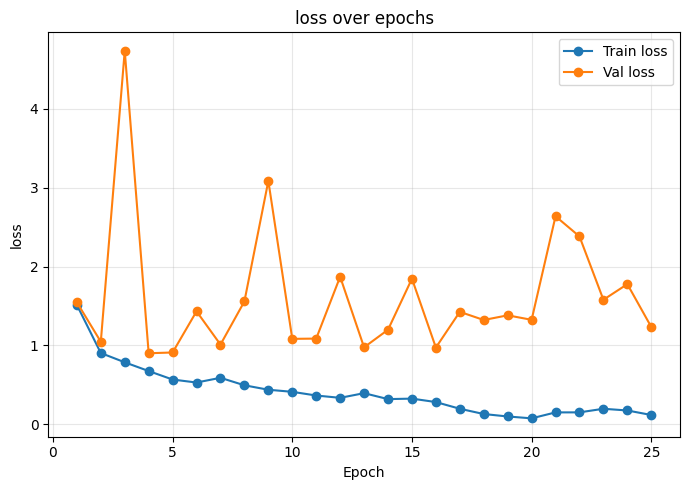

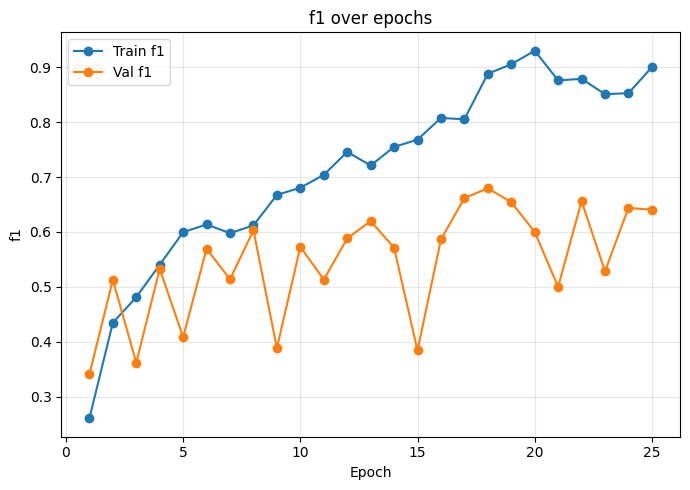

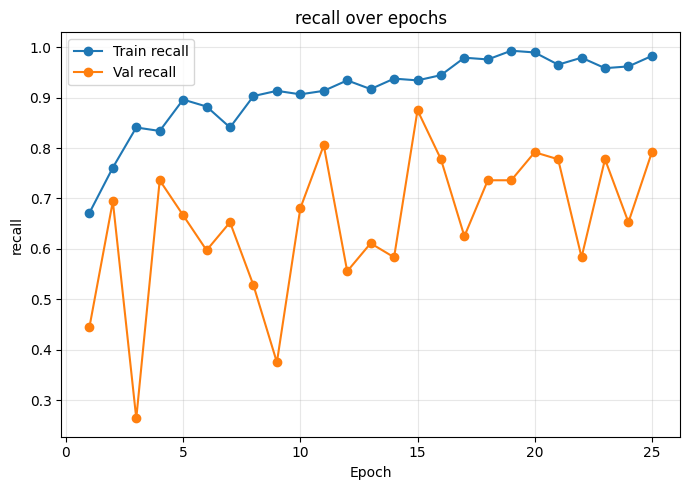

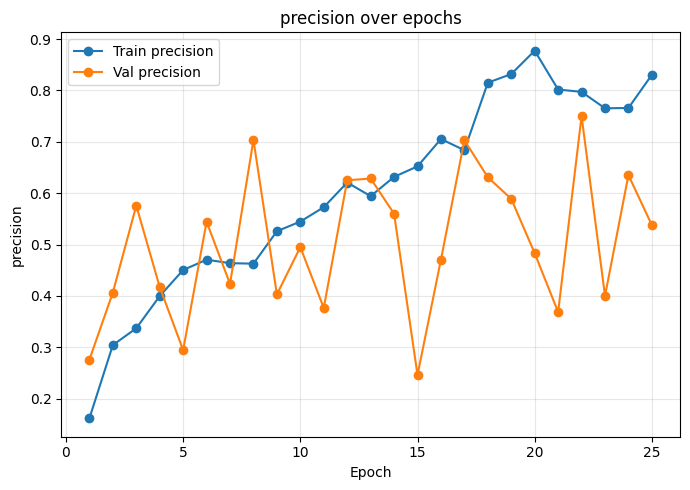

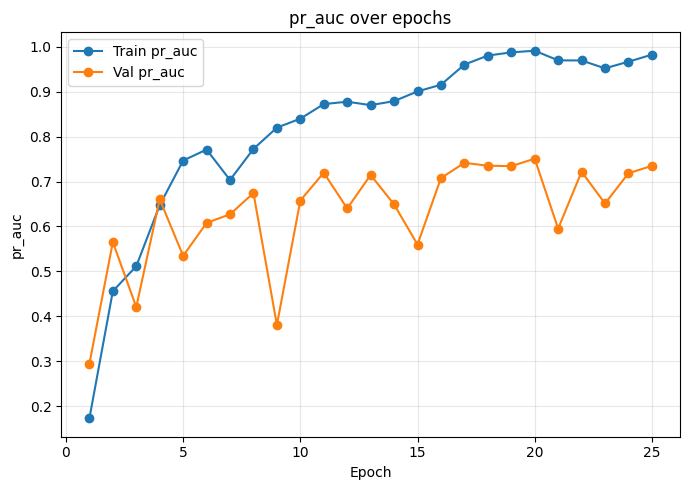

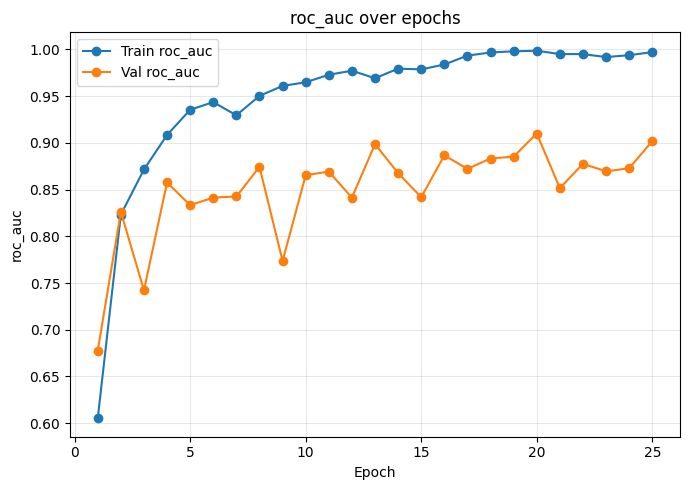

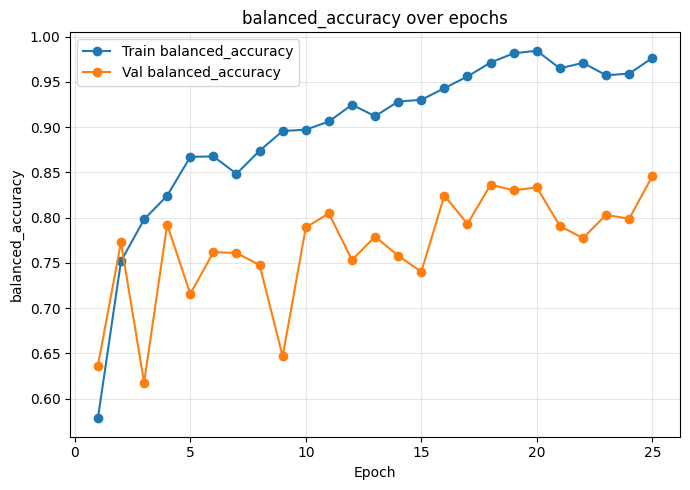

In [17]:
plot_training_history(history)

#multi class classification

In [20]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from tqdm import tqdm


# =========================================================
# 1) DATASET
# =========================================================

class XarrayMulticlassClassificationDataset(Dataset):
    """
    Convert segmentation masks into image-level multiclass labels.

    Each sample returns:
        x: Tensor [C, H, W]
        y: Tensor scalar (class index, dtype=torch.long)

    Parameters
    ----------
    da : xarray.DataArray
        Must contain dimensions including "sample" and "channel".
    label_channel : str
        Name of the segmentation label channel.
    background_class : int
        Background class in segmentation mask.
    mask_to_class_mode : str
        How to convert a mask to a single image-level class:
            - "majority_non_background"
            - "majority_all"
            - "max_present"
    normalize : bool
        Per-channel z-score normalization.
    epsilon : float
        Small value for numerical stability.
    return_sample_id : bool
        Whether to also return sample id.
    """

    def __init__(
        self,
        da,
        label_channel="labels",
        background_class=0,
        mask_to_class_mode="majority_non_background",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
    ):
        self.da = da
        self.label_channel = label_channel
        self.background_class = background_class
        self.mask_to_class_mode = mask_to_class_mode
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found in data.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        if len(self.input_channels) != 11:
            print(f"Warning: expected 11 input channels, found {len(self.input_channels)}")

        # Build image-level labels once
        self.original_labels = self._build_image_level_labels()

        # Keep only classes that actually appear as image labels
        self.present_classes = sorted(np.unique(self.original_labels).tolist())
        self.class_to_index = {cls: idx for idx, cls in enumerate(self.present_classes)}
        self.index_to_class = {idx: cls for cls, idx in self.class_to_index.items()}

        # Store remapped labels [0 .. num_classes-1]
        self.labels = np.array([self.class_to_index[c] for c in self.original_labels], dtype=np.int64)

        self.num_classes = len(self.present_classes)

        print("\nImage-level classes actually present:")
        for cls in self.present_classes:
            count = int((self.original_labels == cls).sum())
            print(f"  original_class={cls}: {count} samples")

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)
        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        return x.astype(np.float32)

    def _mask_to_multiclass_label(self, y_mask: np.ndarray) -> int:
        y_mask = np.asarray(y_mask)
        y_mask = y_mask[~np.isnan(y_mask)]

        if y_mask.size == 0:
            # fallback: treat empty mask as background
            return int(self.background_class)

        y_mask = y_mask.astype(int)

        if self.mask_to_class_mode == "majority_non_background":
            non_bg = y_mask[y_mask != self.background_class]
            if non_bg.size == 0:
                return int(self.background_class)
            unique, counts = np.unique(non_bg, return_counts=True)
            return int(unique[np.argmax(counts)])

        elif self.mask_to_class_mode == "majority_all":
            unique, counts = np.unique(y_mask, return_counts=True)
            return int(unique[np.argmax(counts)])

        elif self.mask_to_class_mode == "max_present":
            return int(np.max(y_mask))

        else:
            raise ValueError(
                f"Unsupported mask_to_class_mode: {self.mask_to_class_mode}. "
                f"Choose from ['majority_non_background', 'majority_all', 'max_present']"
            )

    def _build_image_level_labels(self):
        labels = []
        for i in range(self.da.sizes["sample"]):
            mask = self.da.isel(sample=i).sel(channel=self.label_channel).values
            label = self._mask_to_multiclass_label(mask)
            labels.append(label)
        return np.array(labels, dtype=np.int64)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self.labels[idx]

        x = torch.from_numpy(x)                # [11, H, W]
        y = torch.tensor(y, dtype=torch.long)  # class index for CrossEntropyLoss

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y


# =========================================================
# 2) DATALOADERS
# =========================================================

def make_multiclass_dataloaders(
    da,
    label_channel="labels",
    background_class=0,
    mask_to_class_mode="majority_non_background",
    batch_size=16,
    num_workers=4,
    val_size=0.2,
    random_state=42,
):
    dataset = XarrayMulticlassClassificationDataset(
        da=da,
        label_channel=label_channel,
        background_class=background_class,
        mask_to_class_mode=mask_to_class_mode,
        normalize=True,
        return_sample_id=False,
    )

    labels = dataset.labels
    indices = np.arange(len(dataset))

    unique_classes, counts = np.unique(labels, return_counts=True)
    min_count = counts.min()

    # stratified split only works if each class has at least 2 samples
    if min_count >= 2:
        stratify_labels = labels
        print("\nUsing stratified train/val split.")
    else:
        stratify_labels = None
        print("\nWarning: some classes have <2 samples. Falling back to non-stratified split.")

    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_size,
        random_state=random_state,
        stratify=stratify_labels,
    )

    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    train_labels = labels[train_idx]
    val_labels = labels[val_idx]

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return (
        train_loader,
        val_loader,
        train_labels,
        val_labels,
        dataset.present_classes,
        dataset.class_to_index,
        dataset.index_to_class,
    )


# =========================================================
# 3) MODEL
# =========================================================

class ResNetMulticlassClassifier(nn.Module):
    def __init__(self, in_channels=11, num_classes=2, backbone="resnet50", pretrained=False):
        super().__init__()

        if backbone == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            self.model = models.resnet18(weights=weights)
            in_features = self.model.fc.in_features

        elif backbone == "resnet34":
            weights = models.ResNet34_Weights.DEFAULT if pretrained else None
            self.model = models.resnet34(weights=weights)
            in_features = self.model.fc.in_features

        elif backbone == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            self.model = models.resnet50(weights=weights)
            in_features = self.model.fc.in_features

        else:
            raise ValueError(f"Unsupported backbone: {backbone}")

        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        nn.init.kaiming_normal_(self.model.conv1.weight, mode="fan_out", nonlinearity="relu")

        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)   # [B, num_classes]


# =========================================================
# 4) METRICS
# =========================================================

def compute_multiclass_metrics(y_true, y_pred, num_classes):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(num_classes), average=None, zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "support_per_class": support_per_class,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)),
    }
    return metrics


def print_metrics(prefix, metrics, index_to_class):
    print(
        f"{prefix} | "
        f"loss={metrics['loss']:.4f} "
        f"acc={metrics['accuracy']:.4f} "
        f"bal_acc={metrics['balanced_accuracy']:.4f} "
        f"f1_macro={metrics['f1_macro']:.4f} "
        f"f1_weighted={metrics['f1_weighted']:.4f}"
    )

    print(f"{prefix} per-class:")
    for class_idx in range(len(metrics["f1_per_class"])):
        original_class = index_to_class[class_idx]
        print(
            f"  class_idx={class_idx} (original_class={original_class}) | "
            f"precision={metrics['precision_per_class'][class_idx]:.4f} "
            f"recall={metrics['recall_per_class'][class_idx]:.4f} "
            f"f1={metrics['f1_per_class'][class_idx]:.4f} "
            f"support={metrics['support_per_class'][class_idx]}"
        )


# =========================================================
# 5) CLASS WEIGHTS
# =========================================================

def get_class_weights(train_labels, num_classes):
    train_labels = np.asarray(train_labels)
    counts = np.bincount(train_labels, minlength=num_classes).astype(np.float32)

    weights = np.ones(num_classes, dtype=np.float32)
    nonzero = counts > 0

    # inverse frequency on classes that exist
    weights[nonzero] = len(train_labels) / (nonzero.sum() * counts[nonzero])

    return torch.tensor(weights, dtype=torch.float32), counts


# =========================================================
# 6) TRAIN / VALIDATE
# =========================================================

def train_one_epoch(model, loader, optimizer, criterion, device, num_classes):
    model.train()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    for x, y in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        targets = y.detach().cpu().numpy()

        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_multiclass_metrics(all_targets, all_preds, num_classes=num_classes)
    metrics["loss"] = epoch_loss
    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    for x, y in tqdm(loader, desc="Val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        targets = y.cpu().numpy()

        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_multiclass_metrics(all_targets, all_preds, num_classes=num_classes)
    metrics["loss"] = epoch_loss
    return metrics


# =========================================================
# 7) TRAINING FUNCTION
# =========================================================

def train_model_multiclass(
    da,
    label_channel="labels",
    background_class=0,
    mask_to_class_mode="majority_non_background",
    backbone="resnet50",
    batch_size=16,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=20,
    num_workers=4,
    val_size=0.2,
    random_state=42,
    pretrained=False,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    (
        train_loader,
        val_loader,
        train_labels,
        val_labels,
        present_classes,
        class_to_index,
        index_to_class,
    ) = make_multiclass_dataloaders(
        da=da,
        label_channel=label_channel,
        background_class=background_class,
        mask_to_class_mode=mask_to_class_mode,
        batch_size=batch_size,
        num_workers=num_workers,
        val_size=val_size,
        random_state=random_state,
    )

    num_classes = len(present_classes)

    model = ResNetMulticlassClassifier(
        in_channels=11,
        num_classes=num_classes,
        backbone=backbone,
        pretrained=pretrained,
    ).to(device)

    class_weights, train_counts = get_class_weights(train_labels, num_classes)
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_score = -np.inf

    history = {"train": [], "val": []}

    print("\n======================================")
    print(f"Device: {device}")
    print(f"Backbone: {backbone}")
    print(f"Num image-level classes: {num_classes}")
    print(f"Present original classes: {present_classes}")
    print(f"Class-to-index mapping: {class_to_index}")
    print(f"Train class counts: {train_counts.tolist()}")
    print(f"Class weights: {class_weights.detach().cpu().numpy().tolist()}")
    print("======================================")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            num_classes=num_classes,
        )

        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            num_classes=num_classes,
        )

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print_metrics("Train", train_metrics, index_to_class)
        print_metrics("Val  ", val_metrics, index_to_class)

        current_score = val_metrics["f1_macro"]
        scheduler.step(current_score)

        if current_score > best_score:
            best_score = current_score
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"New best model saved with val f1_macro = {best_score:.4f}")

    model.load_state_dict(best_model_wts)

    print("\nBest validation macro F1:", best_score)

    # Final validation report
    final_val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=num_classes,
    )

    print("\nFinal confusion matrix:")
    print(final_val_metrics["confusion_matrix"])

    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=np.arange(num_classes),
            target_names=[f"class_{index_to_class[i]}" for i in range(num_classes)],
            zero_division=0,
        )
    )

    return model, history, class_to_index, index_to_class


# =========================================================
# 8) RUN
# =========================================================

model, history, class_to_index, index_to_class = train_model_multiclass(
    da=data["data"],
    label_channel="labels",
    background_class=0,                      # set this to your real background class
    mask_to_class_mode="majority_non_background",
    backbone="resnet50",
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=25,
    num_workers=4,
    val_size=0.2,
    random_state=42,
    pretrained=False,                       # usually safer for 11-channel non-RGB
)


Image-level classes actually present:
  original_class=1: 336 samples
  original_class=2: 46 samples
  original_class=3: 114 samples
  original_class=4: 37 samples
  original_class=5: 152 samples
  original_class=6: 351 samples
  original_class=7: 831 samples
  original_class=8: 54 samples
  original_class=9: 39 samples
  original_class=10: 185 samples
  original_class=11: 128 samples
  original_class=12: 169 samples
  original_class=13: 289 samples
  original_class=14: 12 samples
  original_class=15: 60 samples

Using stratified train/val split.

Device: cuda
Backbone: resnet50
Num image-level classes: 15
Present original classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Class-to-index mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14}
Train class counts: [269.0, 37.0, 91.0, 30.0, 121.0, 281.0, 665.0, 43.0, 31.0, 148.0, 102.0, 135.0, 231.0, 10.0, 48.0]
Class weights: [0.5556381940841675, 4.039639472961426, 1.64249

Train | loss=2.9140 acc=0.1842 bal_acc=0.1390 f1_macro=0.1148 f1_weighted=0.2036
Train per-class:
  class_idx=0 (original_class=1) | precision=0.2135 recall=0.0706 f1=0.1061 support=269
  class_idx=1 (original_class=2) | precision=0.0323 recall=0.0270 f1=0.0294 support=37
  class_idx=2 (original_class=3) | precision=0.0787 recall=0.1099 f1=0.0917 support=91
  class_idx=3 (original_class=4) | precision=0.0160 recall=0.1000 f1=0.0275 support=30
  class_idx=4 (original_class=5) | precision=0.1806 recall=0.2149 f1=0.1962 support=121
  class_idx=5 (original_class=6) | precision=0.2239 recall=0.0534 f1=0.0862 support=281
  class_idx=6 (original_class=7) | precision=0.4412 recall=0.3218 f1=0.3722 support=665
  class_idx=7 (original_class=8) | precision=0.0420 recall=0.2791 f1=0.0729 support=43
  class_idx=8 (original_class=9) | precision=0.0467 recall=0.2258 f1=0.0773 support=31
  class_idx=9 (original_class=10) | precision=0.1368 recall=0.0878 f1=0.1070 support=148
  class_idx=10 (original_c

Train | loss=2.3660 acc=0.1485 bal_acc=0.2187 f1_macro=0.1180 f1_weighted=0.1423
Train per-class:
  class_idx=0 (original_class=1) | precision=0.1302 recall=0.0818 f1=0.1005 support=269
  class_idx=1 (original_class=2) | precision=0.0507 recall=0.1892 f1=0.0800 support=37
  class_idx=2 (original_class=3) | precision=0.0769 recall=0.3407 f1=0.1255 support=91
  class_idx=3 (original_class=4) | precision=0.0385 recall=0.0333 f1=0.0357 support=30
  class_idx=4 (original_class=5) | precision=0.1729 recall=0.1901 f1=0.1811 support=121
  class_idx=5 (original_class=6) | precision=0.2800 recall=0.0498 f1=0.0846 support=281
  class_idx=6 (original_class=7) | precision=0.4000 recall=0.0571 f1=0.1000 support=665
  class_idx=7 (original_class=8) | precision=0.0931 recall=0.5349 f1=0.1586 support=43
  class_idx=8 (original_class=9) | precision=0.0576 recall=0.4516 f1=0.1022 support=31
  class_idx=9 (original_class=10) | precision=0.0776 recall=0.1284 f1=0.0967 support=148
  class_idx=10 (original_c

Train | loss=2.2083 acc=0.2596 bal_acc=0.2904 f1_macro=0.1977 f1_weighted=0.2709
Train per-class:
  class_idx=0 (original_class=1) | precision=0.2381 recall=0.0372 f1=0.0643 support=269
  class_idx=1 (original_class=2) | precision=0.0746 recall=0.2703 f1=0.1170 support=37
  class_idx=2 (original_class=3) | precision=0.1180 recall=0.2308 f1=0.1561 support=91
  class_idx=3 (original_class=4) | precision=0.0217 recall=0.0667 f1=0.0328 support=30
  class_idx=4 (original_class=5) | precision=0.2587 recall=0.3058 f1=0.2803 support=121
  class_idx=5 (original_class=6) | precision=0.4108 recall=0.2705 f1=0.3262 support=281
  class_idx=6 (original_class=7) | precision=0.5522 recall=0.2466 f1=0.3410 support=665
  class_idx=7 (original_class=8) | precision=0.1526 recall=0.6744 f1=0.2489 support=43
  class_idx=8 (original_class=9) | precision=0.0785 recall=0.4839 f1=0.1351 support=31
  class_idx=9 (original_class=10) | precision=0.1784 recall=0.2905 f1=0.2211 support=148
  class_idx=10 (original_c

Train | loss=2.0029 acc=0.2667 bal_acc=0.3208 f1_macro=0.2157 f1_weighted=0.2709
Train per-class:
  class_idx=0 (original_class=1) | precision=0.2105 recall=0.0297 f1=0.0521 support=269
  class_idx=1 (original_class=2) | precision=0.1261 recall=0.4054 f1=0.1923 support=37
  class_idx=2 (original_class=3) | precision=0.1747 recall=0.4396 f1=0.2500 support=91
  class_idx=3 (original_class=4) | precision=0.0400 recall=0.0667 f1=0.0500 support=30
  class_idx=4 (original_class=5) | precision=0.2246 recall=0.2562 f1=0.2394 support=121
  class_idx=5 (original_class=6) | precision=0.3042 recall=0.3096 f1=0.3069 support=281
  class_idx=6 (original_class=7) | precision=0.5340 recall=0.2361 f1=0.3274 support=665
  class_idx=7 (original_class=8) | precision=0.1714 recall=0.5581 f1=0.2623 support=43
  class_idx=8 (original_class=9) | precision=0.1239 recall=0.4516 f1=0.1944 support=31
  class_idx=9 (original_class=10) | precision=0.2500 recall=0.2500 f1=0.2500 support=148
  class_idx=10 (original_c

...

Train | loss=0.5516 acc=0.6820 bal_acc=0.8186 f1_macro=0.7504 f1_weighted=0.6759
Train per-class:
  class_idx=0 (original_class=1) | precision=0.5857 recall=0.6097 f1=0.5974 support=269
  class_idx=1 (original_class=2) | precision=0.6140 recall=0.9459 f1=0.7447 support=37
  class_idx=2 (original_class=3) | precision=0.5683 recall=0.8681 f1=0.6870 support=91
  class_idx=3 (original_class=4) | precision=0.8824 recall=1.0000 f1=0.9375 support=30
  class_idx=4 (original_class=5) | precision=0.5608 recall=0.6860 f1=0.6171 support=121
  class_idx=5 (original_class=6) | precision=0.7483 recall=0.8043 f1=0.7753 support=281
  class_idx=6 (original_class=7) | precision=0.7836 recall=0.4737 f1=0.5904 support=665
  class_idx=7 (original_class=8) | precision=0.7647 recall=0.9070 f1=0.8298 support=43
  class_idx=8 (original_class=9) | precision=0.7250 recall=0.9355 f1=0.8169 support=31
  class_idx=9 (original_class=10) | precision=0.6364 recall=0.7568 f1=0.6914 support=148
  class_idx=10 (original_c

Train | loss=0.4485 acc=0.7194 bal_acc=0.8590 f1_macro=0.7853 f1_weighted=0.7125
Train per-class:
  class_idx=0 (original_class=1) | precision=0.6077 recall=0.5874 f1=0.5974 support=269
  class_idx=1 (original_class=2) | precision=0.8605 recall=1.0000 f1=0.9250 support=37
  class_idx=2 (original_class=3) | precision=0.5448 recall=0.8681 f1=0.6695 support=91
  class_idx=3 (original_class=4) | precision=0.7500 recall=1.0000 f1=0.8571 support=30
  class_idx=4 (original_class=5) | precision=0.6024 recall=0.8264 f1=0.6969 support=121
  class_idx=5 (original_class=6) | precision=0.7848 recall=0.8434 f1=0.8130 support=281
  class_idx=6 (original_class=7) | precision=0.8362 recall=0.5068 f1=0.6311 support=665
  class_idx=7 (original_class=8) | precision=0.8542 recall=0.9535 f1=0.9011 support=43
  class_idx=8 (original_class=9) | precision=0.6458 recall=1.0000 f1=0.7848 support=31
  class_idx=9 (original_class=10) | precision=0.6349 recall=0.8108 f1=0.7122 support=148
  class_idx=10 (original_c

Train | loss=0.3933 acc=0.7547 bal_acc=0.8724 f1_macro=0.8167 f1_weighted=0.7510
Train per-class:
  class_idx=0 (original_class=1) | precision=0.6526 recall=0.7472 f1=0.6967 support=269
  class_idx=1 (original_class=2) | precision=0.8043 recall=1.0000 f1=0.8916 support=37
  class_idx=2 (original_class=3) | precision=0.7315 recall=0.8681 f1=0.7940 support=91
  class_idx=3 (original_class=4) | precision=0.8571 recall=1.0000 f1=0.9231 support=30
  class_idx=4 (original_class=5) | precision=0.6400 recall=0.7934 f1=0.7085 support=121
  class_idx=5 (original_class=6) | precision=0.8436 recall=0.8256 f1=0.8345 support=281
  class_idx=6 (original_class=7) | precision=0.8421 recall=0.5534 f1=0.6679 support=665
  class_idx=7 (original_class=8) | precision=0.8750 recall=0.9767 f1=0.9231 support=43
  class_idx=8 (original_class=9) | precision=0.7317 recall=0.9677 f1=0.8333 support=31
  class_idx=9 (original_class=10) | precision=0.7006 recall=0.8378 f1=0.7631 support=148
  class_idx=10 (original_c


Final confusion matrix:
[[32  0  3  1  1  1 17  1  0  5  1  4  0  0  1]
 [ 0  2  5  0  0  0  1  0  0  0  0  1  0  0  0]
 [ 1  1 12  0  0  0  3  0  0  0  3  2  1  0  0]
 [ 2  0  1  0  2  1  1  0  0  0  0  0  0  0  0]
 [ 0  1  0  0 12  1  8  0  0  0  1  4  4  0  0]
 [ 3  1  0  0  0 43  8  0  0  1  5  0  8  0  1]
 [28  1  4  0  2  7 92  0  1  9  7 13  2  0  0]
 [ 0  0  0  0  0  0  0  8  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  1  4  2  0  0  0  0]
 [ 2  0  0  0  0  1  4  2  4 22  1  1  0  0  0]
 [ 2  0  1  1  0  1  2  1  0  0 16  2  0  0  0]
 [ 5  0  1  0  0  0  6  0  0  1  2 16  2  0  1]
 [ 1  0  0  0  1  3  1  0  0  0  2  1 49  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 4  0  0  0  0  1  2  0  0  0  0  0  0  0  5]]



Classification report:
              precision    recall  f1-score   support

     class_1       0.40      0.48      0.43        67
     class_2       0.33      0.22      0.27         9
     class_3       0.44      0.52      0.48        23
     class_4       0.00      0.00      0.00         7
     class_5       0.67      0.39      0.49        31
     class_6       0.73      0.61      0.67        70
     class_7       0.63      0.55      0.59       166
     class_8       0.67      0.73      0.70        11
     class_9       0.17      0.12      0.14         8
    class_10       0.49      0.59      0.54        37
    class_11       0.40      0.62      0.48        26
    class_12       0.36      0.47      0.41        34
    class_13       0.74      0.84      0.79        58
    class_14       0.00      0.00      0.00         2
    class_15       0.62      0.42      0.50        12

    accuracy                           0.55       561
   macro avg       0.44      0.44      0.43       561
we

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


def build_index_to_name(index_to_class, labels_dict):
    return {
        idx: labels_dict[orig_class]
        for idx, orig_class in index_to_class.items()
    }


def _extract_metric(history, split, key):
    return [epoch_metrics[key] for epoch_metrics in history[split]]


def _normalize_confusion_matrix(cm):
    cm = np.asarray(cm, dtype=np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums


def _compute_best_epoch(history, key="f1_macro", split="val"):
    values = _extract_metric(history, split, key)
    return int(np.argmax(values))


def _plot_metric_curves(history, best_epoch):
    epochs = np.arange(1, len(history["train"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    metric_specs = [
        ("loss", "Loss"),
        ("accuracy", "Accuracy"),
        ("balanced_accuracy", "Balanced Accuracy"),
        ("f1_macro", "Macro F1"),
    ]

    for ax, (metric_key, title) in zip(axes, metric_specs):
        train_vals = _extract_metric(history, "train", metric_key)
        val_vals = _extract_metric(history, "val", metric_key)

        ax.plot(epochs, train_vals, marker="o", label="Train")
        ax.plot(epochs, val_vals, marker="o", label="Validation")
        ax.axvline(best_epoch + 1, linestyle="--", label=f"Best epoch = {best_epoch + 1}")
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("Training History", fontsize=16)
    plt.tight_layout()
    plt.show()


def _plot_overfitting_gap(history):
    epochs = np.arange(1, len(history["train"]) + 1)

    train_f1 = np.array(_extract_metric(history, "train", "f1_macro"))
    val_f1 = np.array(_extract_metric(history, "val", "f1_macro"))
    gap_f1 = train_f1 - val_f1

    train_loss = np.array(_extract_metric(history, "train", "loss"))
    val_loss = np.array(_extract_metric(history, "val", "loss"))
    gap_loss = val_loss - train_loss

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, gap_f1, marker="o")
    axes[0].set_title("Macro F1 Gap (Train - Validation)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Gap")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, gap_loss, marker="o")
    axes[1].set_title("Loss Gap (Validation - Train)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Gap")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def _plot_confusion_matrix(cm, class_names, normalize=True, figsize=(14, 11)):
    if normalize:
        display_cm = _normalize_confusion_matrix(cm)
        title = "Normalized Confusion Matrix"
    else:
        display_cm = cm
        title = "Confusion Matrix"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_cm, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    if len(class_names) <= 20:
        for i in range(display_cm.shape[0]):
            for j in range(display_cm.shape[1]):
                val = display_cm[i, j]
                text = f"{val:.2f}" if normalize else f"{int(val)}"
                ax.text(j, i, text, ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()


def _plot_classwise_metrics_from_report(report_dict, class_names):
    precisions = []
    recalls = []
    f1s = []
    supports = []

    for class_name in class_names:
        precisions.append(report_dict[class_name]["precision"])
        recalls.append(report_dict[class_name]["recall"])
        f1s.append(report_dict[class_name]["f1-score"])
        supports.append(report_dict[class_name]["support"])

    x = np.arange(len(class_names))
    width = 0.25

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), height_ratios=[3, 1])

    axes[0].bar(x - width, precisions, width=width, label="Precision")
    axes[0].bar(x, recalls, width=width, label="Recall")
    axes[0].bar(x + width, f1s, width=width, label="F1")
    axes[0].set_title("Per-Class Metrics", fontsize=15)
    axes[0].set_ylabel("Score")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend()

    axes[1].bar(x, supports)
    axes[1].set_title("Validation Support per Class", fontsize=13)
    axes[1].set_ylabel("Count")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


def _plot_f1_only(report_dict, class_names):
    f1s = [report_dict[name]["f1-score"] for name in class_names]
    supports = [report_dict[name]["support"] for name in class_names]

    fig, ax = plt.subplots(figsize=(16, 6))
    bars = ax.bar(np.arange(len(class_names)), f1s)
    ax.set_title("Per-Class F1 Score", fontsize=15)
    ax.set_ylabel("F1")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, support, f1 in zip(bars, supports, f1s):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"n={support}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()


def collect_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())

    return np.array(y_true), np.array(y_pred)


def visualize_training_results_named(
    history,
    y_true,
    y_pred,
    index_to_class,
    labels_dict,
    normalize_confusion=True,
):
    best_epoch = _compute_best_epoch(history, key="f1_macro", split="val")
    index_to_name = build_index_to_name(index_to_class, labels_dict)
    class_names = [index_to_name[i] for i in range(len(index_to_name))]

    print("=" * 80)
    print(f"Best epoch by validation macro F1: {best_epoch + 1}")
    print(f"Best validation macro F1: {history['val'][best_epoch]['f1_macro']:.4f}")
    print(f"Validation accuracy: {history['val'][best_epoch]['accuracy']:.4f}")
    print(f"Validation weighted F1: {history['val'][best_epoch]['f1_weighted']:.4f}")
    print(f"Validation balanced accuracy: {history['val'][best_epoch]['balanced_accuracy']:.4f}")
    print("=" * 80)

    _plot_metric_curves(history, best_epoch)
    _plot_overfitting_gap(history)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    _plot_confusion_matrix(cm, class_names, normalize=normalize_confusion)

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    _plot_classwise_metrics_from_report(report_dict, class_names)
    _plot_f1_only(report_dict, class_names)

    return report_dict, cm, index_to_name

In [23]:
labels_dict = {
    0: "Non-annotated",
    1: "Marine Debris",
    2: "Dense Sargassum",
    3: "Sparse Floating Algae",
    4: "Natural Organic Material",
    5: "Ship",
    6: "Oil Spill",
    7: "Marine Water",
    8: "Sediment-Laden Water",
    9: "Foam",
    10: "Turbid water",
    11: "Shallow Water",
    12: "Waves & Wakes",
    13: "Oil Platform",
    14: "Jellyfish",
    15: "Sea snot"
}


Image-level classes actually present:
  original_class=1: 336 samples
  original_class=2: 46 samples
  original_class=3: 114 samples
  original_class=4: 37 samples
  original_class=5: 152 samples
  original_class=6: 351 samples
  original_class=7: 831 samples
  original_class=8: 54 samples
  original_class=9: 39 samples
  original_class=10: 185 samples
  original_class=11: 128 samples
  original_class=12: 169 samples
  original_class=13: 289 samples
  original_class=14: 12 samples
  original_class=15: 60 samples

Using stratified train/val split.
Best epoch by validation macro F1: 25
Best validation macro F1: 0.4320
Validation accuracy: 0.5526
Validation weighted F1: 0.5508
Validation balanced accuracy: 0.4381


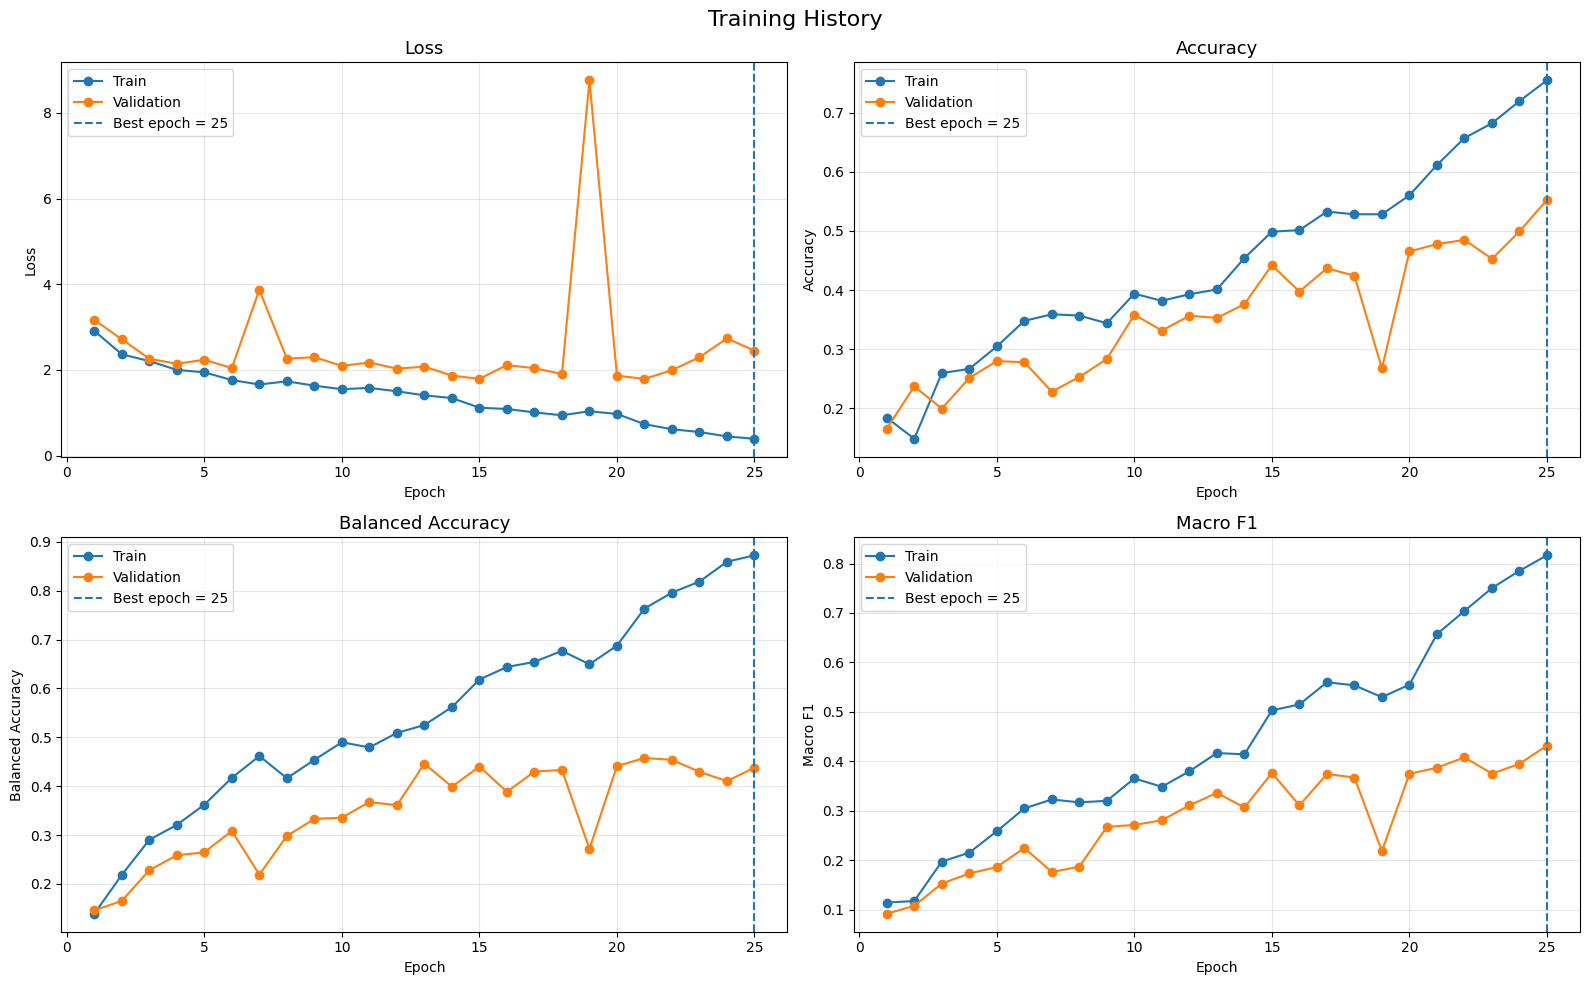

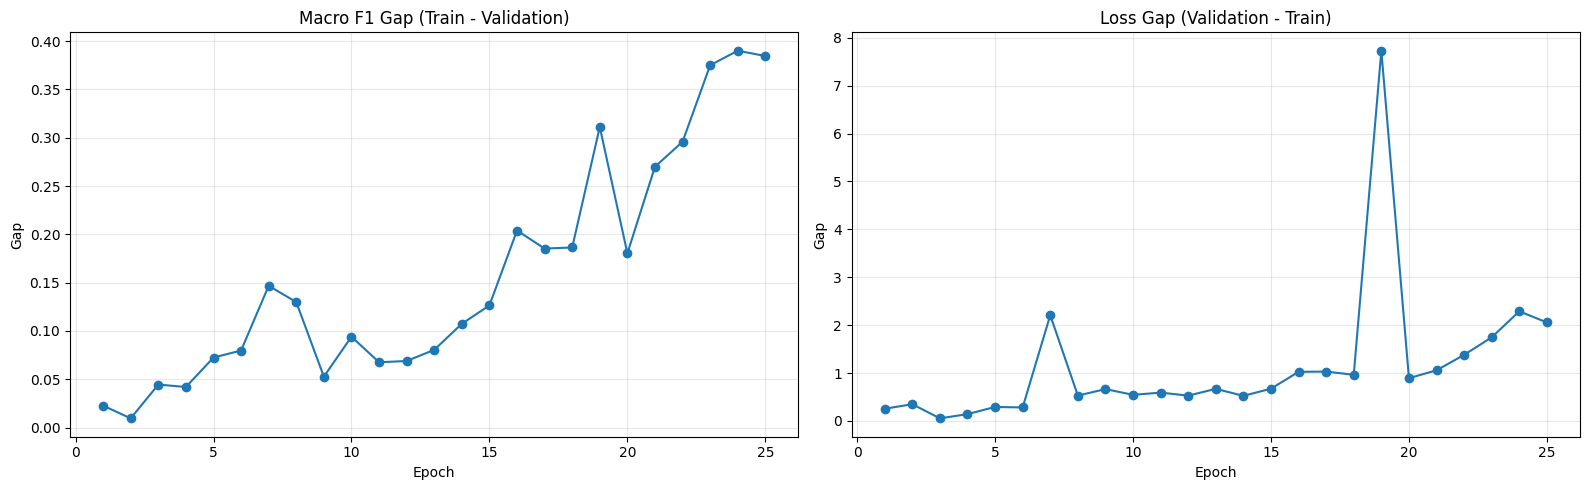

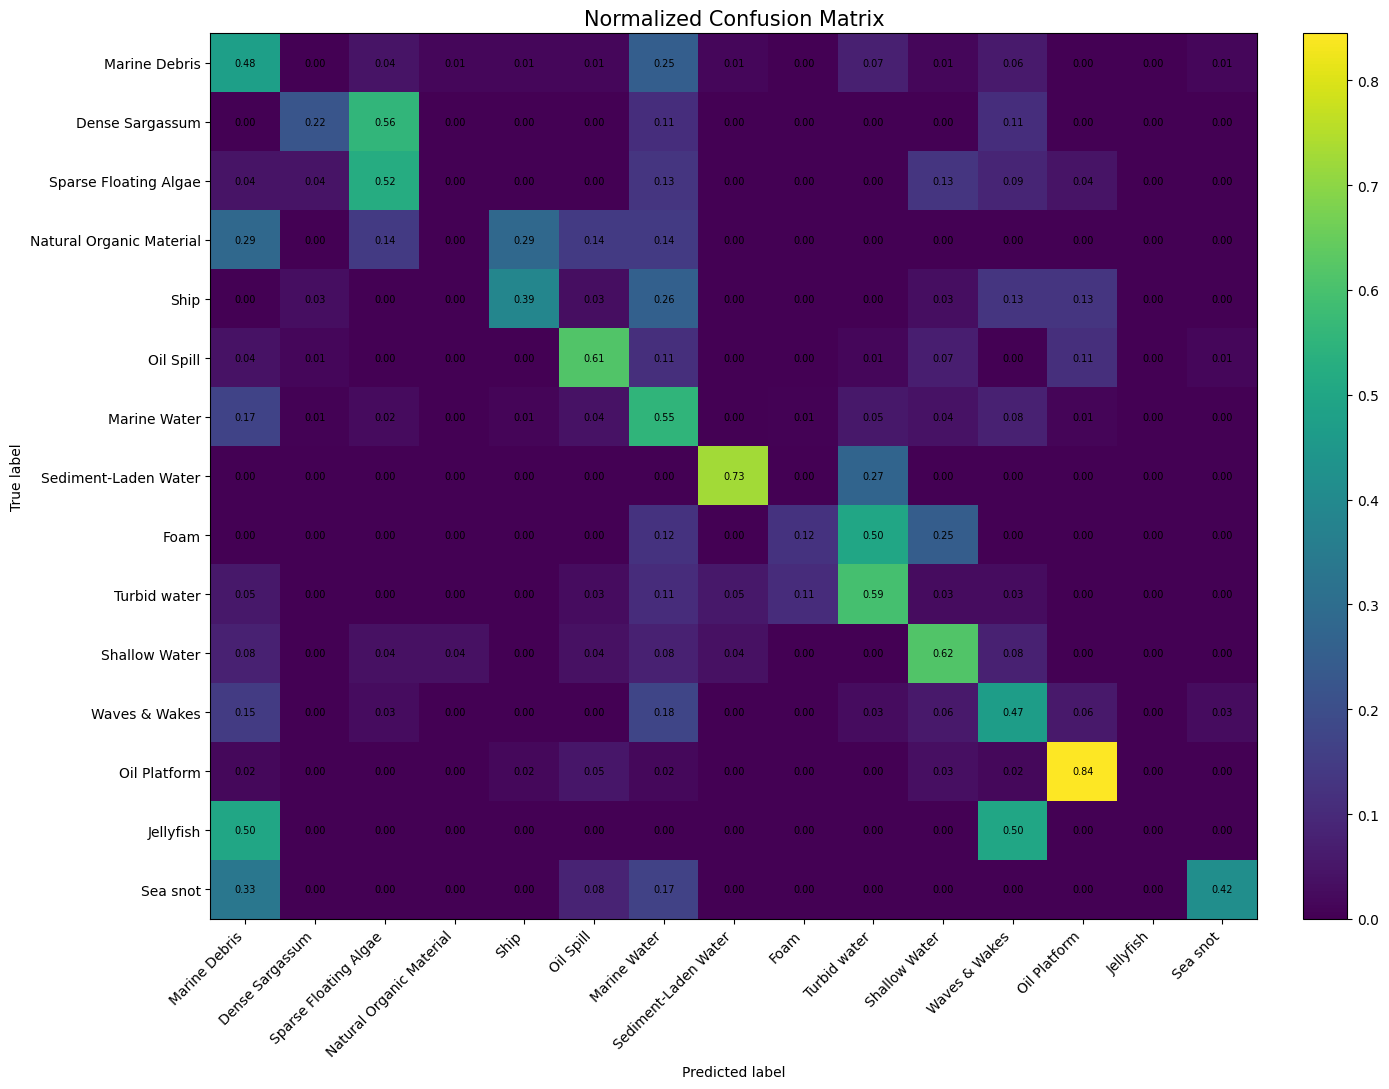

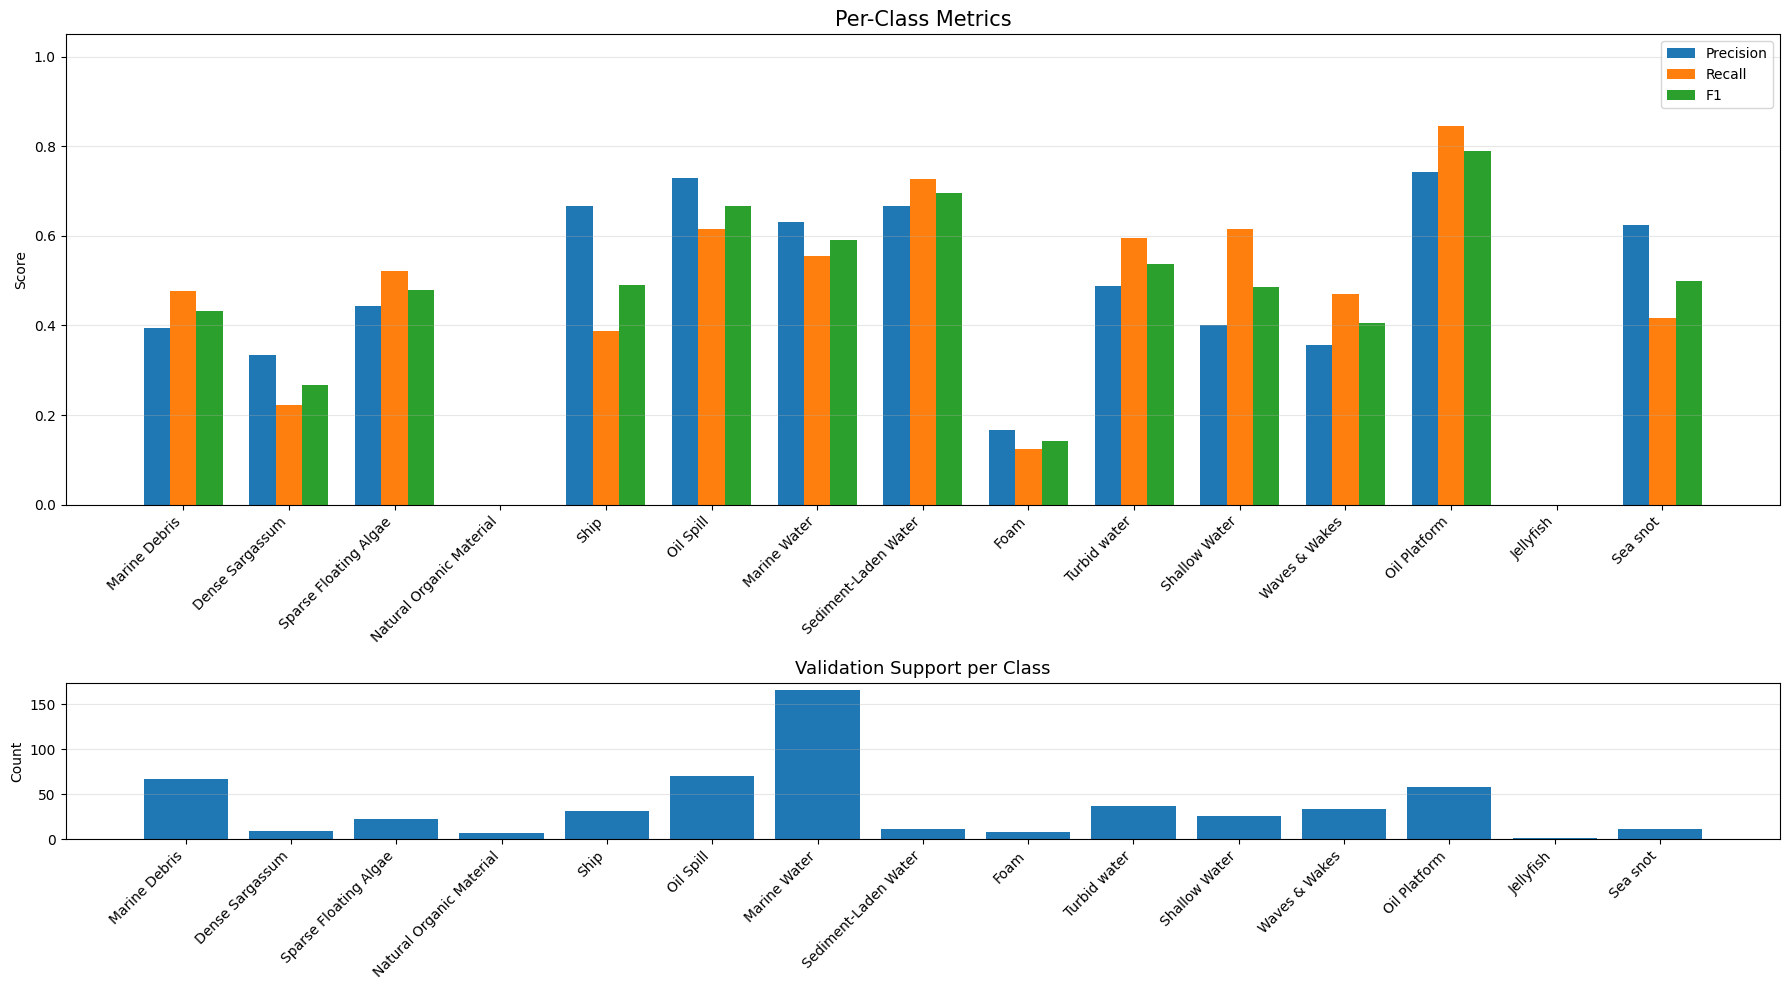

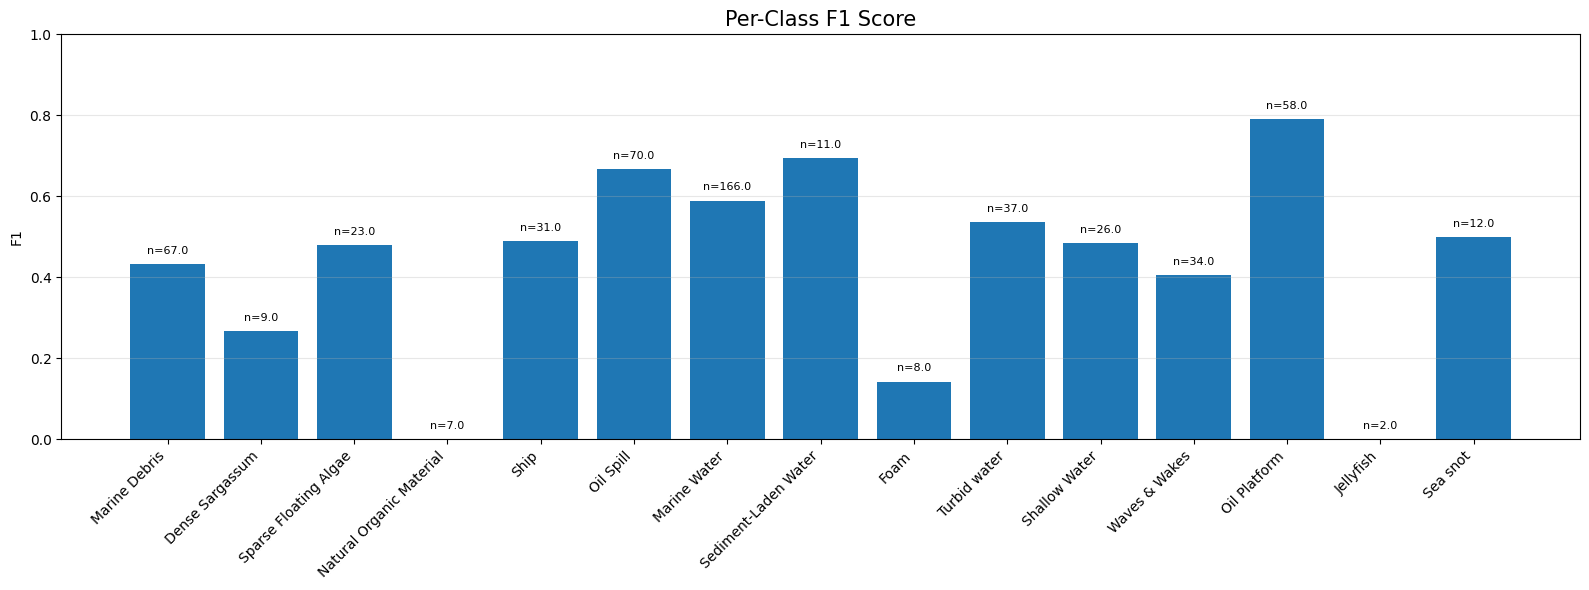

In [24]:
(
    train_loader,
    val_loader,
    train_labels,
    val_labels,
    present_classes,
    class_to_index,
    index_to_class,
) = make_multiclass_dataloaders(
    da=data["data"],
    label_channel="labels",
    background_class=0,
    mask_to_class_mode="majority_non_background",
    batch_size=128,
    num_workers=4,
    val_size=0.2,
    random_state=42,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

y_true, y_pred = collect_predictions(model, val_loader, device)

report_dict, cm, index_to_name = visualize_training_results_named(
    history=history,
    y_true=y_true,
    y_pred=y_pred,
    index_to_class=index_to_class,
    labels_dict=labels_dict,
    normalize_confusion=True,
)

# Data Loader Pytorch

In [13]:
da = data["data"]

image_channels = [ch for ch in da.coords["channel"].values if ch != "labels"]

X_da = da.sel(channel=image_channels)
Y_da = da.sel(channel="labels")

In [ ]:
X_da

<xarray.DataArray 'data' (sample: 2803, channel: 11, x: 240, y: 240)> Size: 7GB
[1775980800 values with dtype=float32]
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 264B '442nm' '492nm' '559nm' ... '1610nm' '2186nm'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239

In [ ]:
print(X_da.shape)
print(Y_da.shape)
print(X_da.dims)
print(Y_da.dims)

(2803, 11, 240, 240)
(2803, 240, 240)
('sample', 'channel', 'x', 'y')
('sample', 'x', 'y')


In [47]:
import numpy as np
import torch
from torch.utils.data import Dataset

import numpy as np
import torch
from torch.utils.data import Dataset


class XarraySegmentationDataset(Dataset):
    def __init__(
        self,
        da,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
        label_mapping=None,
    ):
        self.da = da
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        raw_labels = self.da.sel(channel=self.label_channel).values
        unique_labels = np.unique(raw_labels)

        if label_mapping is None:
            self.label_mapping = {old: new for new, old in enumerate(unique_labels)}
        else:
            self.label_mapping = label_mapping

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)

        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        return x.astype(np.float32)

    def _remap_labels(self, y: np.ndarray) -> np.ndarray:
        y_remapped = np.copy(y)
        for old, new in self.label_mapping.items():
            y_remapped[y == old] = new
        return y_remapped.astype(np.int64)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        y = sample.sel(channel=self.label_channel).values

        # Clean raw input first
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self._remap_labels(y)

        x = torch.from_numpy(x)
        y = torch.from_numpy(y)

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

In [15]:
da = data["data"]

dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

x, y = dataset[0]

print("x shape:", x.shape)   # [C, H, W]
print("y shape:", y.shape)   # [H, W]
print("x dtype:", x.dtype)   # torch.float32
print("y dtype:", y.dtype)   # torch.int64

x shape: torch.Size([11, 240, 240])
y shape: torch.Size([240, 240])
x dtype: torch.float32
y dtype: torch.int64


In [16]:


label_values = np.unique(da.sel(channel="labels").values)
print(label_values)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


In [17]:


label_values = np.unique(da.sel(channel="labels").values)
print("Unique labels:", label_values)
num_classes = len(label_values)
print("Number of classes:", num_classes)

Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Number of classes: 16


In [18]:
from torch.utils.data import random_split, DataLoader

dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
train_loader

# model shshab will be deleeted

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

In [ ]:
in_channels = len(dataset.input_channels)
print("Input channels:", in_channels)
print("Classes:", num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=in_channels, num_classes=num_classes).to(device)
print(model)

Input channels: 11
Classes: 16


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

#check for data sanity

In [13]:
dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

print("Label mapping:", dataset.label_mapping)
num_classes = len(dataset.label_mapping)
print("Num classes:", num_classes)

Label mapping: {np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}
Num classes: 16


In [14]:
batch_x, batch_y = next(iter(train_loader))

print("batch_x has NaN:", torch.isnan(batch_x).any().item())
print("batch_x has inf:", torch.isinf(batch_x).any().item())
print("batch_x min:", batch_x.min().item())
print("batch_x max:", batch_x.max().item())

print("batch_y has NaN:", torch.isnan(batch_y.float()).any().item())
print("batch_y unique:", torch.unique(batch_y))

batch_x has NaN: False
batch_x has inf: False
batch_x min: -10.194828987121582
batch_x max: 115.91560363769531
batch_y has NaN: False
batch_y unique: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


#debuging training
#checking if weights change

# Training

# New Model

In [19]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


# weighted cross entropy loss

In [23]:
from collections import Counter
import torch

def compute_class_weights(dataset, num_classes, ignore_index=None):
    counts = torch.zeros(num_classes, dtype=torch.float)

    for i in range(len(dataset)):
        x, y = dataset[i]   # assumes y is [H, W]
        y = torch.as_tensor(y)

        if ignore_index is not None:
            y = y[y != ignore_index]

        for c in range(num_classes):
            counts[c] += (y == c).sum()

    # inverse frequency
    weights = counts.sum() / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return weights

In [26]:
class_weights = compute_class_weights(
    train_dataset,
    num_classes=num_classes

).to(device)

print("Class weights:", class_weights)

Class weights: tensor([3.5881e-05, 1.1449e+00, 1.4749e+00, 1.3243e+00, 3.9342e+00, 4.2757e-01,
        2.5252e-02, 1.2247e-02, 1.5234e-02, 4.2355e+00, 3.0067e-02, 4.2268e-02,
        2.9337e-01, 3.7486e-01, 2.0552e+00, 6.1021e-01], device='cuda:0')


In [41]:
import numpy as np
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, random_split


# =========================
# 1. Reproducibility
# =========================
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# 2. Build dataset
# =========================
dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

# Read parameters directly from dataset
in_channels = len(dataset.input_channels)
num_classes = len(dataset.label_mapping)

print("Input channels:", in_channels)
print("Num classes:", num_classes)
print("Label mapping:", dataset.label_mapping)


# =========================
# 3. Split dataset
# =========================
set_seed(42)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)


# =========================
# 4. Define model from dataset
# =========================
def build_model_from_dataset(
    dataset,
    encoder_name="resnet34",
    encoder_weights=None,
    device=None,
):
    in_channels = len(dataset.input_channels)
    num_classes = len(dataset.label_mapping)

    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=num_classes,
    )

    if device is not None:
        model = model.to(device)

    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model_from_dataset(
    dataset=dataset,
    encoder_name="resnet34",
    encoder_weights=None,   # use None or "imagenet" if suitable
    device=device,
)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights

)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Input channels: 11
Num classes: 16
Label mapping: {np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}


In [42]:
import torch

def compute_metrics(preds, targets, num_classes, ignore_index=None):
    """
    preds: [B, C, H, W] (logits)
    targets: [B, H, W]
    """
    preds = torch.argmax(preds, dim=1)

    ious = []
    dices = []

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        if ignore_index is not None:
            mask = targets != ignore_index
            pred_cls = pred_cls & mask
            target_cls = target_cls & mask

        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()

        pred_sum = pred_cls.sum().float()
        target_sum = target_cls.sum().float()

        if union == 0:
            iou = torch.tensor(1.0)  # perfect if both empty
        else:
            iou = intersection / union

        if (pred_sum + target_sum) == 0:
            dice = torch.tensor(1.0)
        else:
            dice = 2 * intersection / (pred_sum + target_sum)

        ious.append(iou)
        dices.append(dice)

    mean_iou = torch.stack(ious).mean().item()
    mean_dice = torch.stack(dices).mean().item()

    return mean_iou, mean_dice

In [43]:
# =========================
# 5. Training and validation loops
# =========================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device)                  # [B, C, H, W]
        y = y.to(device).long()           # [B, H, W]

        optimizer.zero_grad()

        logits = model(x)                 # [B, num_classes, H, W]
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes, ignore_index=None):
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            iou, dice = compute_metrics(
                outputs, masks,
                num_classes=num_classes,
                ignore_index=ignore_index
            )

            total_iou += iou
            total_dice += dice

    return (
        total_loss / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )



In [45]:
x, y = dataset[0]
print(torch.unique(torch.as_tensor(y)))
print(dataset.label_mapping)

tensor([0, 6])
{np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}


In [44]:
# =========================
# 6. Full training loop
# =========================
num_epochs = 50
best_val_iou = 0.0
best_model_path = "best_unet_model_WeightedcrossEntropy_loss_.pth"
IGNORE_INDEX = None

history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_iou, val_dice = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=num_classes,
        ignore_index=IGNORE_INDEX,   # set this if you have unlabeled pixels
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model to {best_model_path} (best Val IoU: {best_val_iou:.4f})")

Epoch [1/50] Train Loss: 3.2331 | Val Loss: 2598.1627 | Val IoU: 0.0000 | Val Dice: 0.0001
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0000)
Epoch [2/50] Train Loss: 2.6700 | Val Loss: 19.5396 | Val IoU: 0.0057 | Val Dice: 0.0108
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0057)
Epoch [3/50] Train Loss: 2.5314 | Val Loss: 2.9722 | Val IoU: 0.0115 | Val Dice: 0.0199
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0115)
Epoch [4/50] Train Loss: 2.3740 | Val Loss: 2.6082 | Val IoU: 0.0143 | Val Dice: 0.0252
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0143)
Epoch [5/50] Train Loss: 2.2721 | Val Loss: 2.3850 | Val IoU: 0.0139 | Val Dice: 0.0242
Epoch [6/50] Train Loss: 2.1020 | Val Loss: 2.1792 | Val IoU: 0.0152 | Val Dice: 0.0261
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0152)
Epoch [7

KeyboardInterrupt: 

#Plot Metrics

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # =========================
    # 1. Loss plot
    # =========================
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()
    plt.grid(True)

    # =========================
    # 2. Metrics plot
    # =========================
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_iou"], label="Val IoU")
    plt.plot(epochs, history["val_dice"], label="Val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Segmentation Metrics")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(history)

In [ ]:
def smooth_curve(values, factor=0.8):
    smoothed = []
    for v in values:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + v * (1 - factor))
        else:
            smoothed.append(v)
    return smoothed

In [ ]:
plt.plot(epochs, smooth_curve(history["val_iou"]), label="Val IoU (smooth)")